Epoch =    1 | Loss = 1.507570
Epoch =   10 | Loss = 0.527760
Epoch =   50 | Loss = 0.067091
Epoch =  100 | Loss = 0.034283
Epoch =  500 | Loss = 0.015929
Epoch = 1000 | Loss = 0.009276
Epoch = 2000 | Loss = 0.005069
Epoch = 3000 | Loss = 0.003581
Epoch = 4000 | Loss = 0.002809
Epoch = 5000 | Loss = 0.002330

FINAL HOUSE PRICE PREDICTIONS
Area   Bedrooms   Age    Actual   Predicted
-----------------------------------------------
1.0     2         15     35.00      35.53
1.2     2         10     42.00      42.26
1.5     3         8     52.00      51.55
1.8     3         5     65.00      63.50
2.0     3         4     72.00      71.30
2.2     4         3     82.00      82.68
2.5     4         2     95.00      95.96
2.8     4         1     108.00      109.88
3.0     5         1     120.00      121.81
3.2     5         0     135.00      131.51

NEW HOUSE PREDICTION
Area      : 2.4 thousand sq.ft.
Bedrooms  : 4
Age       : 3 years
Predicted Price: ₹90.03 Lakhs


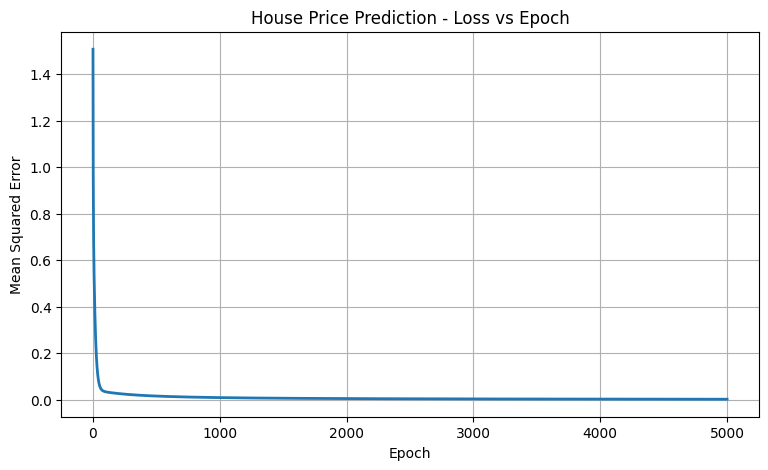

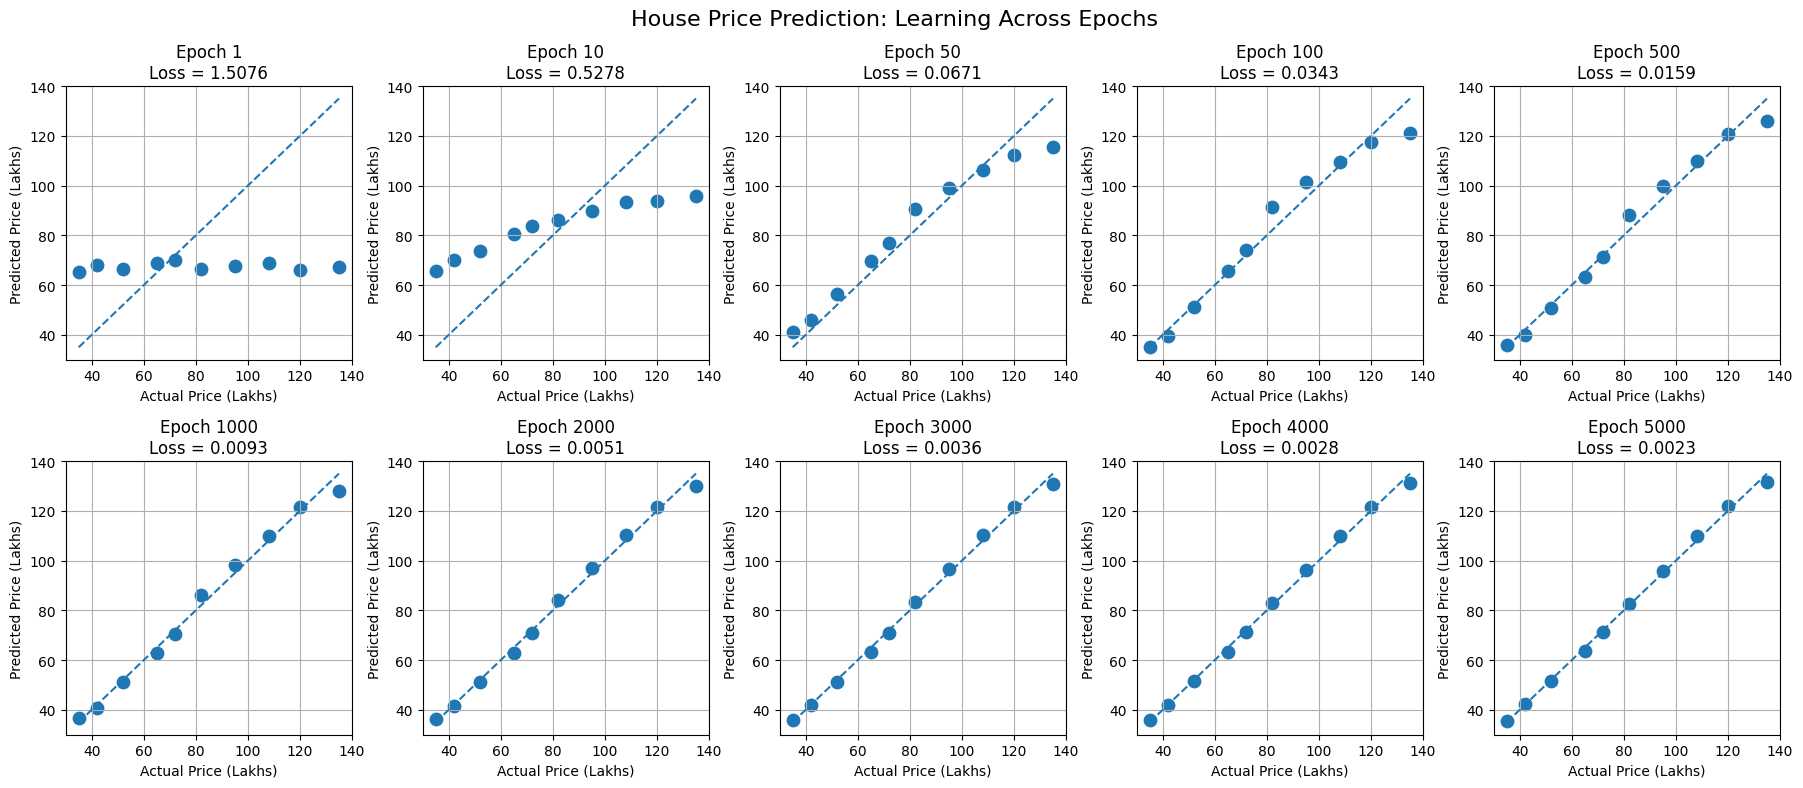

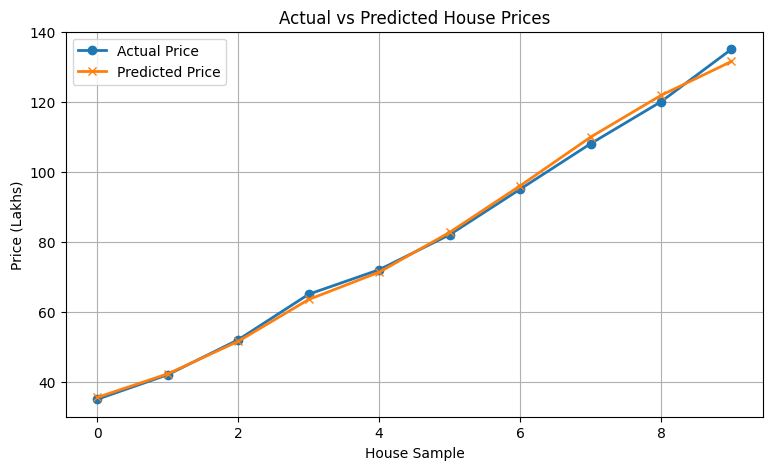

In [ ]:
# ============================================================
# HOUSE PRICE PREDICTION USING BACKPROPAGATION
# EPOCH-WISE EXECUTION AND VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. HOUSE PRICE DATASET
# ============================================================
# Features:
# X1 = Area in 1000 sq.ft.
# X2 = Number of bedrooms
# X3 = Age of house in years
#
# Target:
# House price in lakhs
# ============================================================

X = np.array([
    [1.0, 2, 15],
    [1.2, 2, 10],
    [1.5, 3, 8],
    [1.8, 3, 5],
    [2.0, 3, 4],
    [2.2, 4, 3],
    [2.5, 4, 2],
    [2.8, 4, 1],
    [3.0, 5, 1],
    [3.2, 5, 0]
], dtype=float)

# House prices in lakhs
y = np.array([
    [35],
    [42],
    [52],
    [65],
    [72],
    [82],
    [95],
    [108],
    [120],
    [135]
], dtype=float)


# ============================================================
# 2. NORMALIZE INPUT DATA
# ============================================================

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_norm = (X - X_mean) / X_std


# Normalize target
y_mean = y.mean()
y_std = y.std()

y_norm = (y - y_mean) / y_std


# ============================================================
# 3. SIGMOID ACTIVATION FUNCTION
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)


# ============================================================
# 4. INITIALIZE NEURAL NETWORK
# ============================================================

np.random.seed(42)

input_neurons = 3
hidden_neurons = 6
output_neurons = 1

# Input → Hidden
W1 = np.random.randn(
    input_neurons,
    hidden_neurons
) * 0.5

b1 = np.zeros(
    (1, hidden_neurons)
)

# Hidden → Output
W2 = np.random.randn(
    hidden_neurons,
    output_neurons
) * 0.5

b2 = np.zeros(
    (1, output_neurons)
)


# ============================================================
# 5. TRAINING PARAMETERS
# ============================================================

learning_rate = 0.05
epochs = 5000

loss_history = []

# Epochs to display
display_epochs = [
    1,
    10,
    50,
    100,
    500,
    1000,
    2000,
    3000,
    4000,
    5000
]

epoch_records = []


# ============================================================
# 6. BACKPROPAGATION TRAINING
# ============================================================

for epoch in range(1, epochs + 1):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    # Input → Hidden
    Z1 = np.dot(X_norm, W1) + b1

    A1 = sigmoid(Z1)

    # Hidden → Output
    Z2 = np.dot(A1, W2) + b2

    # Linear output for regression
    A2 = Z2


    # --------------------------------------------------------
    # CALCULATE MEAN SQUARED ERROR
    # --------------------------------------------------------

    error = A2 - y_norm

    loss = np.mean(error ** 2)

    loss_history.append(loss)


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # Output layer gradient
    dZ2 = 2 * error / len(X)

    dW2 = np.dot(
        A1.T,
        dZ2
    )

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )


    # Hidden layer gradient
    dA1 = np.dot(
        dZ2,
        W2.T
    )

    dZ1 = (
        dA1 *
        sigmoid_derivative(A1)
    )

    dW1 = np.dot(
        X_norm.T,
        dZ1
    )

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )


    # --------------------------------------------------------
    # UPDATE WEIGHTS
    # --------------------------------------------------------

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1


    # --------------------------------------------------------
    # STORE EPOCH INFORMATION
    # --------------------------------------------------------

    if epoch in display_epochs:

        epoch_records.append({
            "epoch": epoch,
            "loss": loss,
            "W1": W1.copy(),
            "W2": W2.copy(),
            "b1": b1.copy(),
            "b2": b2.copy()
        })

        print(
            f"Epoch = {epoch:4d} | "
            f"Loss = {loss:.6f}"
        )


# ============================================================
# 7. FINAL PREDICTION
# ============================================================

Z1 = np.dot(X_norm, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2

predicted_price = (
    Z2 * y_std
    + y_mean
)


# ============================================================
# 8. DISPLAY FINAL RESULTS
# ============================================================

print("\n================================================")
print("FINAL HOUSE PRICE PREDICTIONS")
print("================================================")

print(
    "Area   Bedrooms   Age    Actual   Predicted"
)

print("-----------------------------------------------")

for i in range(len(X)):

    print(
        f"{X[i,0]:.1f}     "
        f"{int(X[i,1])}         "
        f"{int(X[i,2])}     "
        f"{y[i,0]:.2f}      "
        f"{predicted_price[i,0]:.2f}"
    )


# ============================================================
# 9. PREDICT PRICE FOR A NEW HOUSE
# ============================================================

new_house = np.array([
    [2.4, 4, 3]
], dtype=float)

# Normalize using training statistics
new_house_norm = (
    new_house - X_mean
) / X_std

# Forward propagation
hidden = sigmoid(
    np.dot(new_house_norm, W1) + b1
)

prediction_norm = (
    np.dot(hidden, W2) + b2
)

prediction = (
    prediction_norm * y_std
    + y_mean
)

print("\n================================================")
print("NEW HOUSE PREDICTION")
print("================================================")

print(
    f"Area      : {new_house[0,0]} thousand sq.ft."
)

print(
    f"Bedrooms  : {int(new_house[0,1])}"
)

print(
    f"Age       : {int(new_house[0,2])} years"
)

print(
    f"Predicted Price: ₹{prediction[0,0]:.2f} Lakhs"
)


# ============================================================
# 10. VISUALIZE LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.title(
    "House Price Prediction - Loss vs Epoch"
)

plt.grid(True)

plt.show()


# ============================================================
# 11. VISUALIZE EPOCH-WISE PREDICTIONS
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, record in zip(
    axes.ravel(),
    epoch_records
):

    # --------------------------------------------
    # Forward propagation using saved weights
    # --------------------------------------------

    hidden = sigmoid(
        np.dot(
            X_norm,
            record["W1"]
        )
        +
        record["b1"]
    )

    output_norm = (
        np.dot(
            hidden,
            record["W2"]
        )
        +
        record["b2"]
    )

    output = (
        output_norm * y_std
        + y_mean
    )


    # --------------------------------------------
    # Plot actual vs predicted
    # --------------------------------------------

    ax.scatter(
        y,
        output,
        s=80,
        label="Predicted"
    )

    # Perfect prediction line
    minimum = min(
        y.min(),
        output.min()
    )

    maximum = max(
        y.max(),
        output.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect prediction"
    )

    ax.set_xlabel(
        "Actual Price (Lakhs)"
    )

    ax.set_ylabel(
        "Predicted Price (Lakhs)"
    )

    ax.set_title(
        f"Epoch {record['epoch']}\n"
        f"Loss = {record['loss']:.4f}"
    )

    ax.grid(True)


plt.suptitle(
    "House Price Prediction: Learning Across Epochs",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. VISUALIZE ACTUAL VS FINAL PREDICTED PRICE
# ============================================================

plt.figure(figsize=(9, 5))

indices = np.arange(len(y))

plt.plot(
    indices,
    y.flatten(),
    marker="o",
    linewidth=2,
    label="Actual Price"
)

plt.plot(
    indices,
    predicted_price.flatten(),
    marker="x",
    linewidth=2,
    label="Predicted Price"
)

plt.xlabel("House Sample")
plt.ylabel("Price (Lakhs)")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.legend()

plt.grid(True)

plt.show()

                FORWARD PROPAGATION
                       │
                       ▼
             Calculate prediction
                       │
                       ▼
                 Calculate MSE
                       │
                       ▼
                BACKPROPAGATION
                       │
                       ▼
             Calculate gradients
                       │
                       ▼
              Update W1, W2, b1, b2
                       │
                       ▼
                   Next Epoch
                   

Epoch 1       → Large error
Epoch 10      → Error starts decreasing
Epoch 100     → Predictions improve
Epoch 500     → Network learns relationships
Epoch 1000    → Smaller error
Epoch 2500    → Better predictions
Epoch 5000    → Converged solution









